### Author: Celia Baumhoer (2025)

In [ ]:
import shutil
from pathlib import Path

import rasterio
from rasterio.warp import transform_bounds
from shapely.geometry import Polygon, box

In [55]:
def reproject_bbox(bbox: Polygon, src_crs: str, dst_crs: str) -> Polygon:
    """
    Reprojects a bbox (Polygon) from src_crs to dst_crs.
    Returns a new Polygon in dst_crs.
    """
    minx, miny, maxx, maxy = bbox.bounds
    t_minx, t_miny, t_maxx, t_maxy = transform_bounds(
        src_crs, dst_crs, minx, miny, maxx, maxy, densify_pts=21
    )
    return box(t_minx, t_miny, t_maxx, t_maxy)


def get_raster_footprint(dataset: rasterio.DatasetReader) -> Polygon:
    """
    Returns the bounding box of a raster dataset as a Polygon.
    """
    bounds = dataset.bounds
    return box(bounds.left, bounds.bottom, bounds.right, bounds.top)


def raster_intersects_bbox(raster_path: Path, bbox: Polygon) -> bool:
    """
    Opens a raster, checks CRS, transforms bbox if needed,
    and tests intersection.
    """
    with rasterio.open(raster_path) as ds:
        raster_crs = ds.crs
        if raster_crs is None:
            return False  # Non-georeferenced or invalid; skip

        # Ensure CRS alignment
        if raster_crs.to_string() != "EPSG:4326":
            bbox_in_raster_crs = reproject_bbox(
                bbox, src_crs="EPSG:4326", dst_crs=raster_crs.to_string()
            )
        else:
            bbox_in_raster_crs = bbox

        raster_poly = get_raster_footprint(ds)
        return raster_poly.intersects(bbox_in_raster_crs)

## Seperate Test Scenes for Canada

In [88]:
# configuration
in_path = Path("/dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat")
src_dir = in_path / "fsc_raw"
dst_dir = in_path / "fsc_raw_rockies"
dst_dir.mkdir(exist_ok=True)

# Bounding box Rockies + Canadian Mountains
# box in EPSG:4326 (lat/lon)
rockies_bbox_wgs84 = box(-145.0, 48.0, -114.0, 65.0)  # (minx, miny, maxx, maxy)

In [63]:
# copy to rockies folder
tif_files = list(src_dir.rglob("*.tif"))

for tif in tif_files:
    if raster_intersects_bbox(tif, rockies_bbox_wgs84):
        shutil.move(str(tif), dst_dir / tif.name)
        print(f"Moved: {tif.name}")
    else:
        print(f"Skipped: {tif.name}")

Skipped: LC09_L2SP_147038_20220606_20220608_02_T1_snowclass_QA.tif
Skipped: LC09_L2SP_140041_20230216_20230310_02_T1_snowclass_QA.tif
Skipped: LC09_L2SP_136040_20230119_20230313_02_T1_snowclass_QA.tif
Skipped: LC09_L2SP_152035_20230119_20230313_02_T1_snowclass_QA.tif
Skipped: LC09_L2SP_228011_20220629_20220701_02_T1_snowclass_QA.tif
Skipped: LC09_L2SP_171031_20221223_20230317_02_T1_snowclass_QA.tif
Skipped: LC09_L2SP_071018_20220601_20220603_02_T1_snowclass_QA.tif
Skipped: LC09_L2SP_169034_20230227_20230308_02_T1_snowclass_QA.tif
Skipped: LC09_L2SP_081012_20220927_20221003_02_T1_snowclass_QA.tif
Skipped: LC09_L2SP_145039_20230102_20230315_02_T1_snowclass_QA.tif
Skipped: LC08_L2SP_151034_20220626_20220706_02_T1_snowclass_QA.tif
Skipped: LC09_L2SP_133033_20220604_20220606_02_T1_snowclass_QA.tif
Skipped: LC09_L2SP_165027_20230303_20230307_02_T1_snowclass_QA.tif
Moved: LC09_L2SP_048022_20220819_20220822_02_T1_snowclass_QA.tif
Skipped: LC09_L2SP_037029_20220923_20220925_02_T1_snowclass_QA.t

### Sanity check

In [89]:
src_raw = src_dir
src_rockies = dst_dir  # expected to already exist

In [90]:
def raster_bbox_polygon_wgs84(tif_path: Path):
    """
    Return a shapely Polygon of the raster bounding box in EPSG:4326.
    Returns None if unreadable or unreferenced.
    """
    try:
        with rasterio.open(tif_path) as ds:
            if ds.crs is None:
                return None

            b = ds.bounds
            ds_crs = ds.crs.to_string()

            if ds_crs == "EPSG:4326":
                return box(b.left, b.bottom, b.right, b.top)

            # Reproject bbox -> WGS84
            minx, miny, maxx, maxy = transform_bounds(
                ds_crs, "EPSG:4326", b.left, b.bottom, b.right, b.top, densify_pts=21
            )
            return box(minx, miny, maxx, maxy)
    except:
        return None

In [91]:
# polygons fsc_raw
tifs_raw = sorted(src_raw.rglob("*.tif"))
polys_raw = []
for tif in tifs_raw:
    poly = raster_bbox_polygon_wgs84(tif)
    if poly is not None:
        polys_raw.append(poly)

gdf_raw = gpd.GeoDataFrame(
    {"path": [str(p) for p in tifs_raw[: len(polys_raw)]]}, geometry=polys_raw, crs="EPSG:4326"
)

In [92]:
# polygons fsc_rockies
tifs_rockies = sorted(src_rockies.rglob("*.tif"))
polys_rockies = []
for tif in tifs_rockies:
    poly = raster_bbox_polygon_wgs84(tif)
    if poly is not None:
        polys_rockies.append(poly)

gdf_rockies = gpd.GeoDataFrame(
    {"path": [str(p) for p in tifs_rockies[: len(polys_rockies)]]},
    geometry=polys_rockies,
    crs="EPSG:4326",
)

In [93]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)

world empty? False
raw empty? False
rockies empty? False


/dss/dsstbyfs02/scratch/05/di93dix/di93dix/tmp.Pw6ma5Cd0b/ipykernel_138025/1743086707.py:46: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/dss/dsstbyfs02/scratch/05/di93dix/di93dix/tmp.Pw6ma5Cd0b/ipykernel_138025/1743086707.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


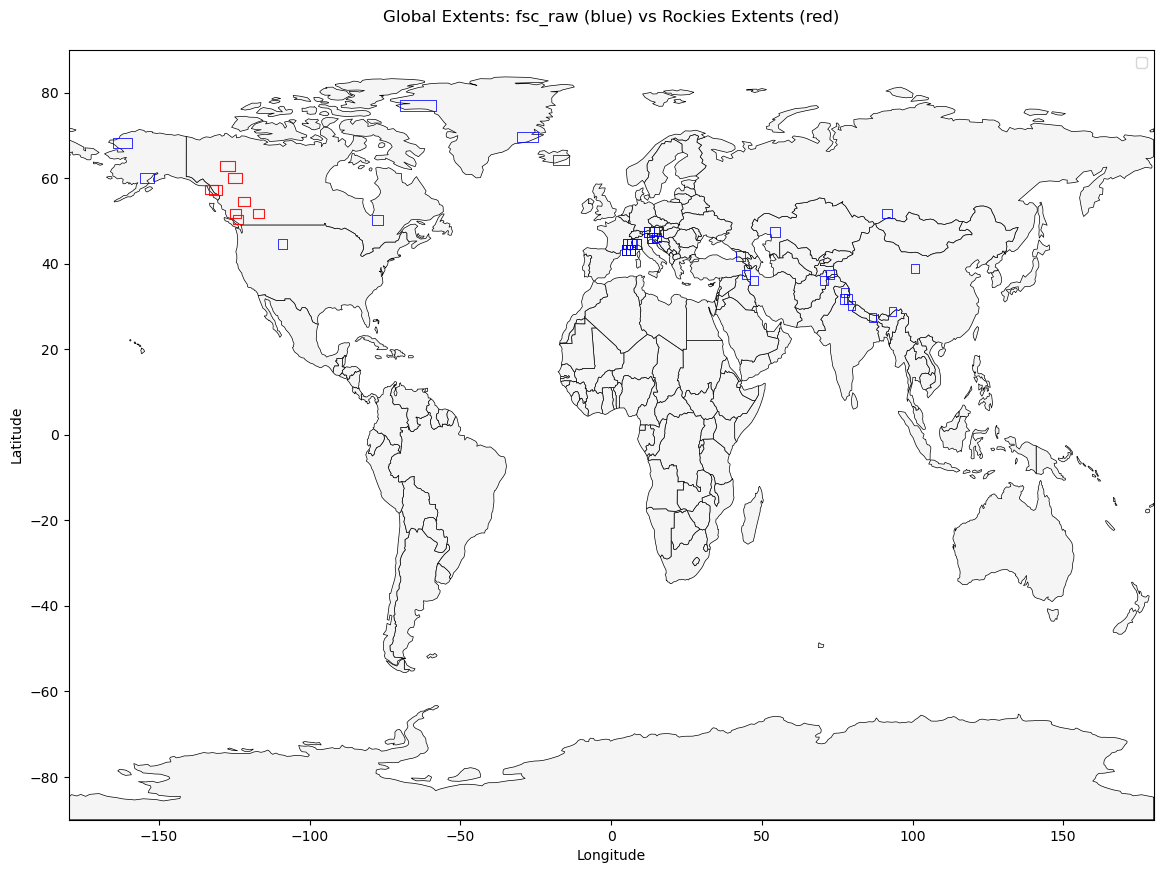

In [94]:
fig, ax = plt.subplots(figsize=(14, 10))

# Ensure none of the GeoDataFrames are empty
print("world empty?", world.empty)
print("raw empty?", gdf_raw.empty)
print("rockies empty?", gdf_rockies.empty)

# World map first
if not world.empty:
    world.plot(ax=ax, color="whitesmoke", edgecolor="black", linewidth=0.5, zorder=0)
else:
    print("WARNING: World GeoDataFrame is empty. Check your file path.")

# Raw extent footprints
if not gdf_raw.empty:
    gdf_raw.plot(
        ax=ax,
        color="none",
        edgecolor="blue",
        linewidth=0.7,
        alpha=0.8,
        zorder=1,
        label="fsc_raw (all scenes)",
    )

# Rockies extent footprints
if not gdf_rockies.empty:
    gdf_rockies.plot(
        ax=ax,
        color="none",
        edgecolor="red",
        linewidth=0.8,
        alpha=0.9,
        zorder=2,
        label="Rockies subset",
    )

# Force a stable aspect ratio for global maps
ax.set_aspect("auto")  # <-- this prevents the ValueError
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

ax.set_title("Global Extents: fsc_raw (blue) vs Rockies Extents (red)", pad=20)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.savefig("/dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat/train_test_split.png")
plt.show()

## Seperate Test Scenes Switzerland

In [71]:
# configuration
in_path = Path("/dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat")
src_dir = in_path / "fsc_raw_alps"
dst_dir = in_path / "fsc_raw_switzerland"
dst_dir.mkdir(exist_ok=True)

# Bounding box Rockies + Canadian Mountains
# box in EPSG:4326 (lat/lon)
ch_bbox_wgs84 = box(5.96, 45.82, 10.49, 47.81)  # (minx, miny, maxx, maxy)

In [ ]:
# copy to switzerland folder
tif_files = list(src_dir.rglob("*.tif"))

for tif in tif_files:
    if raster_intersects_bbox(tif, ch_bbox_wgs84):
        shutil.move(str(tif), dst_dir / tif.name)
        print(f"Moved: {tif.name}")
    else:
        print(f"Skipped: {tif.name}")

In [79]:
len(os.listdir(src_dir))

65

In [83]:
# temporal distribution
import re
from collections import Counter
from pathlib import Path

year_regex = re.compile(r".*_(\d{4})\d{4}_")

# Collect all years
years = []
for tif in src_dir.rglob("*.tif"):
    m = year_regex.match(tif.name)
    if not m:
        continue
    year = int(m.group(1))
    years.append(year)

# Count occurrences
year_counts = Counter(years)

# Print counts sorted by year
for year in sorted(year_counts):
    print(f"{year}: {year_counts[year]} files")

2020: 18 files
2021: 47 files


## Select a subset for test (remaining scenes are in folder OLD if more is needed)

### 21 random scenes available over the Alps go into fsc_raw as training data. Then we have 21 global scenes and 21 from the Alps.

In [85]:
import random
import shutil
from pathlib import Path

# Paths
in_path = Path("/dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat")
fsc_raw = in_path / "fsc_raw"
src_dir = in_path / "fsc_raw_alps"

# List all files (e.g., .tif)
all_files = list(src_dir.glob("*.tif"))

# Pick 21 random files
random_files = random.sample(all_files, k=21)

In [87]:
# Copy files to destination
for f in random_files:
    shutil.copy(f, fsc_raw / f.name)

print(f"Copied {len(random_files)} files to {fsc_raw}")

Copied 21 files to /dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat/fsc_raw


### Keep 8 test scenes of Switzerland, from each month one between Sep 2020 and April 2021

In [103]:
import random
import re
from collections import defaultdict
from pathlib import Path

# Paths
in_path = Path("/dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat")
src_dir = in_path / "fsc_raw_switzerland"
fsc_raw = in_path / "fsc_raw_switzerland_keep"

# Example filename: LC08_L2SP_193027_20210221_20210303_02_T1_snowclass_QA.tif
date_regex = re.compile(r"^[^_]+_[^_]+_[^_]+_(\d{8})_")

# List all files
all_files = list(src_dir.glob("*.tif"))

# Group files by month
files_by_month = defaultdict(list)
for f in all_files:
    match = date_regex.match(f.name)
    if match:
        date_str = match.group(1)
        month = int(date_str[4:6])
        # Select months Sept (9) to Dec (12) and Jan (1) to Apr (4)
        if month >= 9 or month <= 4:
            files_by_month[month].append(f)

# Pick one random file per month
random_files_per_month = {
    month: random.choice(files) for month, files in files_by_month.items() if files
}

# Flatten to list if needed
random_files = list(random_files_per_month.values())
random_files

[PosixPath('/dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat/fsc_raw_switzerland/LC08_L2SP_194028_20201226_20210310_02_T1_snowclass_QA.tif'),
 PosixPath('/dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat/fsc_raw_switzerland/LC08_L2SP_195028_20201030_20201106_02_T1_snowclass_QA.tif'),
 PosixPath('/dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat/fsc_raw_switzerland/LC08_L2SP_196028_20210415_20210424_02_T1_snowclass_QA.tif'),
 PosixPath('/dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat/fsc_raw_switzerland/LC08_L2SP_194027_20210228_20210311_02_T1_snowclass_QA.tif'),
 PosixPath('/dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat/fsc_raw_switzerland/LC08_L2SP_195028_20210118_20210306_02_T1_snowclass_QA.tif'),
 PosixPath('/dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat/fsc_raw_switzerland/LC08_L2SP_196028_20200903_20200918_02_T1_snowclass_QA.tif'),
 PosixPath('/dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat/fsc_raw_switzerland/LC08

In [105]:
# Copy files to destination
for f in random_files:
    shutil.copy(f, fsc_raw / f.name)

print(f"Copied {len(random_files)} files to {fsc_raw}")

Copied 8 files to /dss/dsstbyfs02/pn49ci/pn49ci-dss-0013/evaluation/Landsat/fsc_raw_switzerland_keep
